# Assignment 3: Diffusion Playground

In this problem set you will play around with diffusion models, implement diffusion sampling loops, and use them for other tasks such as inpainting and creating optical illusions.

# Part 0: Setup

### Using DeepFloyd

We are going to use the [DeepFloyd IF](https://huggingface.co/docs/diffusers/api/pipelines/deepfloyd_if) diffusion model. DeepFloyd is a two stage model trained by Stability AI. The first stage produces images of size $64 \times 64$ and the second stage takes the outputs of the first stage and generates images of size $256 \times 256$. We provide upsampling code at the very end of the notebook, though this is not required in your submission.

Before using DeepFloyd, you must accept its usage conditions. To do so:

1. Make a [Hugging Face account](https://huggingface.co/join) and log in.
2. Accept the license on the model card of [DeepFloyd/IF-I-L-v1.0](https://huggingface.co/DeepFloyd/IF-I-L-v1.0). Accepting the license on the stage I model card will auto accept for the other IF models.
3. Create a [Hugging Face Hub access token](https://huggingface.co/docs/hub/security-tokens#what-are-user-access-tokens) [here](https://huggingface.co/settings/tokens) (a read token is enough for this project). You'll use it to log in after installing dependencies below.


### Install Dependencies

Run the below to install dependencies.

In [1]:
! pip install -q "huggingface_hub<1.0" --force-reinstall --no-deps
! pip install -q \
  diffusers \
  "transformers<5" \
  safetensors \
  sentencepiece \
  accelerate \
  bitsandbytes \
  einops \
  mediapy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.7 MB/s eta 0:00:00


### Log in to Hugging Face

Now that dependencies are installed, run the cell below and paste your token into the widget that appears.


In [5]:
from huggingface_hub import notebook_login

notebook_login()

### Import Dependencies

The cell below imports useful packages we will need, and setup the device that we're using.

In [6]:
from PIL import Image
import mediapy as media
from pprint import pprint
from tqdm import tqdm

import torch
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
from diffusers import DiffusionPipeline
from transformers import T5EncoderModel

# For downloading web images
import requests
from io import BytesIO

device = 'cuda'

import huggingface_hub
if not hasattr(huggingface_hub.constants, "HF_HUB_ENABLE_HF_TRANSFER"):
    huggingface_hub.constants.HF_HUB_ENABLE_HF_TRANSFER = False


### Loading the models

We will need to download and create the two DeepFloyd stages. These models are quite large, so this cell may take a minute or two to run.

In [8]:
# Load DeepFloyd IF stage I
stage_1 = DiffusionPipeline.from_pretrained(
    "DeepFloyd/IF-I-L-v1.0",
    text_encoder=None,
    variant="fp16",
    torch_dtype=torch.float16,
)
stage_1.to(device)

# Load DeepFloyd IF stage II
stage_2 = DiffusionPipeline.from_pretrained(
                "DeepFloyd/IF-II-L-v1.0",
                text_encoder=None,
                variant="fp16",
                torch_dtype=torch.float16,
              )
stage_2.to(device)


A mixture of fp16 and non-fp16 filenames will be loaded.
Loaded fp16 filenames:
[text_encoder/model.fp16-00002-of-00002.safetensors, safety_checker/model.fp16.safetensors, unet/diffusion_pytorch_model.fp16.safetensors, text_encoder/model.fp16-00001-of-00002.safetensors, text_encoder/model.safetensors.index.fp16.json, text_encoder/pytorch_model.bin.index.fp16.json]
Loaded non-fp16 filenames:
[watermarker/diffusion_pytorch_model.safetensors
If this behavior is not expected, please check your folder structure.


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.87G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


...

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/2.49G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

watermarker/diffusion_pytorch_model.safe(…):   0%|          | 0.00/15.5k [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

IFSuperResolutionPipeline {
  "_class_name": "IFSuperResolutionPipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "DeepFloyd/IF-II-L-v1.0",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_noising_scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "deepfloyd_if",
    "IFSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "text_encoder": [
    null,
    null
  ],
  "tokenizer": [
    "transformers",
    "T5Tokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "watermarker": [
    "deepfloyd_if",
    "IFWatermarker"
  ]
}

### Play with the Model using Your Own Text Prompts!

DeepFloyd was trained as a text-to-image model, which takes text prompts as input and outputs images that are aligned with the text. However, a raw text string cannot be directly used as the model's input — we first need to convert it into a high-dimensional vector (of 4096 dimensions in our case) that the model can understand, a.k.a. prompt embeddings.

Running the T5 text encoder yourself is optional and **not required** for this assignment. Instead, we provide a precomputed dictionary of prompt embeddings covering a fixed set of prompts (`prompt_embeds_dict.pth`) — this is the intended way to complete every task below. Run the cell below, print the available keys, and choose from that list for each task.

If you want to encode prompts of your own choosing beyond this fixed set, you are welcome to run the T5 encoder yourself locally in this notebook (`transformers.T5EncoderModel`), but this is slower and entirely optional.


In [9]:
# By default, load the course-provided precomputed embeddings.
!wget https://raw.githubusercontent.com/saradorfman1/Assignment3/main/prompt_embeds_dict.pth -O prompt_embeds_dict.pth
prompt_embeds_dict = torch.load('prompt_embeds_dict.pth')

# If you generated your own .pth file (e.g. by running the T5 encoder yourself
# on additional prompts), you can load it instead:
# prompt_embeds_dict = torch.load('/PATH_TO_YOUR_EMBEDDINGS')

print("You have the embeddings for the following prompts")
pprint(list(prompt_embeds_dict.keys()))


--2026-07-08 19:56:15--  https://raw.githubusercontent.com/saradorfman1/Assignment3/main/prompt_embeds_dict.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8836210 (8.4M) [application/octet-stream]
Saving to: ‘prompt_embeds_dict.pth’

prompt_embeds_dict. 100%[===================>]   8.43M  --.-KB/s    in 0.07s   

2026-07-08 19:56:15 (114 MB/s) - ‘prompt_embeds_dict.pth’ saved [8836210/8836210]

You have the embeddings for the following prompts
['an oil painting of a snowy mountain village',
 'a photo of the amalfi cost',
 'a photo of a man',
 'a photo of a hipster barista',
 'a photo of a dog',
 'an oil painting of people around a campfire',
 'an oil painting of an old man',
 'a lithograph of waterfalls',
 'a lithograph of a skull',
 'a man wearing a ha

By default, we've automatically added the prompt `"a high quality photo"` and the empty prompt `""` to your dictionary. We want you to think of them as "null" prompts that don't have any specific meaning, and are simply a way for the model to do unconditional generation. You can view them as using the diffusion model to "force" a noisy image onto the "manifold" of real images. We will introduce them in a more detailed way in later sections.

### Seed your Work
To reproduce your code, please use a random seed from this point onward. Running two runtimes with the same seed will give you identical generation results.

However, the outputs also depend on how many times you run each cell in each runtime, which is harder to keep track of than the seed. Therefore, please **immediately download and save any images you like**, as you may not be able to reproduce them once the notebook runtime expires.

In [10]:
def seed_everything(seed):
  torch.cuda.manual_seed(seed)
  torch.manual_seed(seed)

YOUR_SEED = 100
seed_everything(YOUR_SEED)

### Sampling from the Model

The objects instantiated above, `stage_1` and `stage_2`, already contain code to allow us to sample images using these models. Read the code below carefully (including the comments) and then run the cell to generate some images. Play around with different prompts and `num_inference_steps`.

### Deliverables
- Choose 3 prompts from the precomputed dictionary (or your own, if you generate embeddings yourself) and display the caption and output for each. Briefly reflect on the quality of the outputs and their relationship to the prompts. Try at least 2 different `num_inference_steps` values on one image and show before/after.
- Report the random seed you used. Use the same seed for all subsequent parts.


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

an oil painting of an old man,an oil painting of people around a campfire,a rocket ship

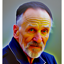
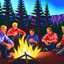
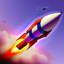

an oil painting of an old man,an oil painting of people around a campfire,a rocket ship

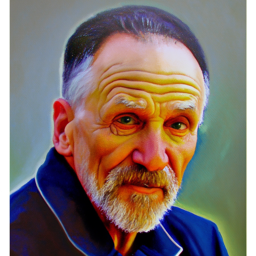
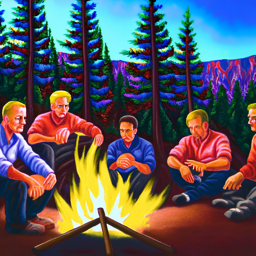
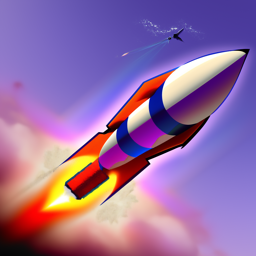

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

a rocket ship — 5 inference steps

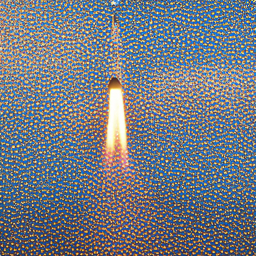

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

a rocket ship — 50 inference steps

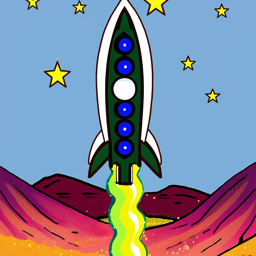

In [11]:
# Get prompt embeddings from the precomputed cache.
# `prompt_embeds` is of shape [N, 77, 4096]
# 77 comes from the max sequence length that deepfloyd will take
# and 4096 comes from the embedding dimension of the text encoder

prompts = [
    # TODO: Choose 3 of your prompts here
    "an oil painting of an old man",
    "an oil painting of people around a campfire",
    "a rocket ship",

]
prompt_embeds = torch.cat([
    prompt_embeds_dict[prompt] for prompt in prompts
], dim=0)
negative_prompt_embeds = torch.cat(
    [prompt_embeds_dict['']] * len(prompts)
)

# Sample from stage 1
# Outputs a [N, 3, 64, 64] torch tensor
# num_inference_steps is an integer between 1 and 1000, indicating how many
# denoising steps to take: lower is faster, at the cost of reduced quality
stage_1_output = stage_1(
    prompt_embeds=prompt_embeds,
    negative_prompt_embeds=negative_prompt_embeds,
    num_inference_steps=20,
    output_type="pt"
).images

# Sample from stage 2
# Outputs a [N, 3, 256, 256] torch tensor
stage_2_output = stage_2(
    image=stage_1_output,
    num_inference_steps=20,
    prompt_embeds=prompt_embeds,
    negative_prompt_embeds=negative_prompt_embeds,
    output_type="pt",
).images

# Display images
media.show_images(
    stage_1_output.permute(0, 2, 3, 1).cpu() / 2. + 0.5,
    titles=prompts)
media.show_images(
    stage_2_output.permute(0, 2, 3, 1).cpu() / 2. + 0.5,
    titles=prompts)


compare_prompt = "a rocket ship"
cmp_embeds = prompt_embeds_dict[compare_prompt]
cmp_neg = prompt_embeds_dict['']

for steps in [5, 50]:
    s1 = stage_1(
        prompt_embeds=cmp_embeds,
        negative_prompt_embeds=cmp_neg,
        num_inference_steps=steps,
        output_type="pt",
    ).images
    s2 = stage_2(
        image=s1,
        num_inference_steps=steps,
        prompt_embeds=cmp_embeds,
        negative_prompt_embeds=cmp_neg,
        output_type="pt",
    ).images
    media.show_images(
        s2.permute(0, 2, 3, 1).cpu() / 2. + 0.5,
        titles=[f"{compare_prompt} — {steps} inference steps"])


# Part 1: Sampling Loops

In this part of the problem set, you will write your own "sampling loops" that use the pretrained DeepFloyd denoisers. These should produce high quality images such as the ones generated above.

You will then modify these sampling loops to solve different tasks such as inpainting or producing optical illusions. In all of these cases, you will be able to keep the diffusion model fixed, and simply changing the sampling loop.


In [12]:
# Get scheduler parameters
alphas_cumprod = stage_1.scheduler.alphas_cumprod
print(f"We have in total {alphas_cumprod.shape[0]} noise coefficients")

We have in total 1000 noise coefficients


We provide a test image that you can work with

--2026-07-08 19:57:24--  https://raw.githubusercontent.com/saradorfman1/Assignment3/main/campanile.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 75608 (74K) [image/jpeg]
Saving to: ‘campanile.jpg’

campanile.jpg       100%[===================>]  73.84K  --.-KB/s    in 0.01s   

2026-07-08 19:57:25 (6.87 MB/s) - ‘campanile.jpg’ saved [75608/75608]

Test image:


""

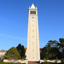

In [13]:
# Get test image
!wget https://raw.githubusercontent.com/saradorfman1/Assignment3/main/campanile.jpg -O campanile.jpg
test_im = Image.open('campanile.jpg')

# For stage 1: Resize to (64, 64), convert to tensor, rescale to [-1, 1], and
# add a batch dimension. The result is a (1, 3, 64, 64) tensor
test_im = Image.open('campanile.jpg').resize((64, 64))
test_im = TF.to_tensor(test_im)
test_im = 2 * test_im - 1
test_im = test_im[None]

# Show test image
print('Test image:')
media.show_image(test_im[0].permute(1,2,0) / 2. + 0.5)

# 1.1 The Forward Process

**Disclaimer about equations**: Colab sometimes cannot correctly render the math equations below. Please cross-reference them with the assignment PDF to make sure that you're looking at the fully correct equation.

A key part of diffusion is the forward process, which takes a clean image and adds noise to it. This uses the exact same formula you already implemented in Assignment 2 -- just against a schedule pulled from the pretrained model's scheduler instead of one you build yourself, and for a single timestep rather than a training batch. `forward(im, t)` is provided below; read it and make sure you understand each line before moving on.

### Deliverables
- Noisy test image at $t \in$ [250, 500, 750]


In [14]:
# Provided: same formula as your Assignment 2 forward process, using the pretrained model's schedule.
def forward(im, t):
  """
  Args:
    im : torch tensor of size (1, 3, 64, 64) representing the clean image
    t : integer timestep

  Returns:
    im_noisy : torch tensor of size (1, 3, 64, 64) representing the noisy image at timestep t
  """
  with torch.no_grad():
    alpha_cumprod = alphas_cumprod[t]
    eps = torch.randn_like(im)
    im_noisy = torch.sqrt(alpha_cumprod) * im + torch.sqrt(1 - alpha_cumprod) * eps
  return im_noisy


original,t = 250,t = 500,t = 750

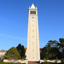
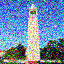
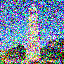
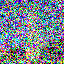

In [15]:
# Show the test image at noise level [250, 500, 750]
# ===== your code here! =====
noisy_images = {'original': test_im[0].permute(1, 2, 0) / 2. + 0.5}
for t in [250, 500, 750]:
    im_noisy = forward(test_im, t)
    noisy_images[f't = {t}'] = im_noisy[0].permute(1, 2, 0) / 2. + 0.5

media.show_images(noisy_images)

# ===== end of code =====

# 1.2 Denoising: One-Step vs. Iterative

Now, we'll use a pretrained diffusion model to denoise. The actual denoiser can be found at `stage_1.unet`. This is a UNet that has already been trained on a *very, very* large dataset of $(x_0, x_t)$ pairs of images. We can use it to recover Gaussian noise from the image, and by extension, recover something close to the original image. Note, though, that this UNet is not particularly good, so if the noise is too big, it will hallucinate a new image!

**(a) One-step denoising.** One way to use this UNet to denoise is to estimate the entire noise in one shot, and subtract this noise from the noisy image. This is not a great method, since it makes a very large estimate, but it is a good way to sanity check our approach.

Recall that $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon$. Given an estimate of $\epsilon$ from the UNet, we can recover an estimate of the original image $x_0$ via algebraic manipulation of the above equation.

### Deliverables
- Original test image
- Noisy test image at $t \in$ [250, 500, 750]
- Estimate of the original image using one-step denoising for the same values of $t$


original,noisy t=250,one-step t=250,noisy t=500,one-step t=500,noisy t=750,one-step t=750

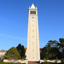
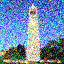
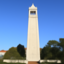
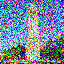
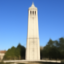
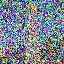
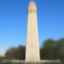

In [16]:
# Please use the null prompt embedding
prompt_embeds = prompt_embeds_dict["a high quality photo"]
results = {'original': test_im[0].permute(1, 2, 0) / 2. + 0.5}

with torch.no_grad():
  for t in [250, 500, 750]:
    # Get alpha bar
    alpha_cumprod = alphas_cumprod[t]

    # Run forward process
    # ===== your code here! =====

    im_noisy = forward(test_im, t)

    # ===== end of code =====

    # Estimate noise in noisy image
    noise_est = stage_1.unet(
        im_noisy.half().cuda(),
        t,
        encoder_hidden_states=prompt_embeds,
        return_dict=False
    )[0]

    # Take only first 3 channels, and move result to cpu
    noise_est = noise_est[:, :3].cpu()

    # Remove the noise
    # run `.detach().numpy()` on the image so we can display it
    # ===== your code here! =====
    x0 = (im_noisy - torch.sqrt(1 - alpha_cumprod) * noise_est) / torch.sqrt(alpha_cumprod)
    x0 = x0.detach().numpy()

    results[f'noisy t={t}'] = im_noisy[0].permute(1, 2, 0) / 2. + 0.5
    results[f'one-step t={t}'] = x0[0].transpose(1, 2, 0) / 2. + 0.5
    # ===== end of code =====

media.show_images(results)


**(b) Iterative denoising.** In (a), you should see that the results get worse as you add more noise. This makes sense, as the problem is much harder with more noise! But diffusion models are designed to denoise iteratively. In this part we will implement this.

In theory, we can perform this iteratively denoising the image at every single one of the 1000 timesteps. However, this is quite slow, and one of the major contributions of the DDPM paper (Denoising Diffusion Probabilistic Models) is that we can *skip* steps as long as we adjust the amount of noise added/removed accordingly. The image below illustrates the idea: we only evaluate the model on a strided subset of timesteps, and the update rule accounts for the larger jump.


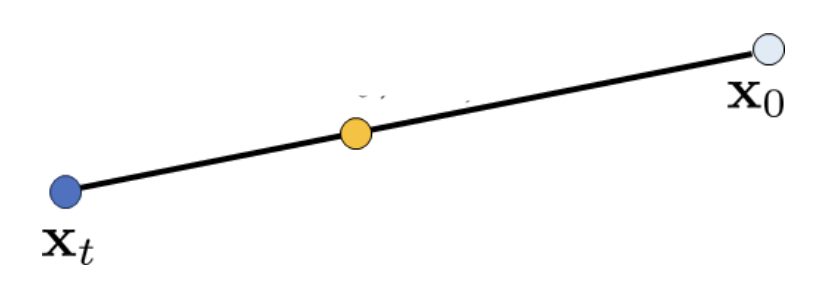

See equations 6 and 7 of the [DDPM paper](https://arxiv.org/pdf/2006.11239) for the full derivation. Be careful about variable naming -- the notebook uses $\bar\alpha_t$ for the paper's $\bar\alpha_t$, $\alpha_t$ for the paper's $\alpha_t$, and $\beta_t$ for the paper's $\beta_t$; make sure you look up the correct value in `alphas_cumprod`.

### Deliverables
- The list of strided timesteps you use
- Noisy test image at $i\_start = 10$
- The iteratively denoised test image (final result)

**Comparison.** At the very end of the `iterative_denoise` cell below, also compute the one-step estimate of the same noisy image (reuse your code from part (a)) and display it side by side with the iterative result. In your writeup, discuss why iterative denoising outperforms one-step denoising, especially at this noise level.


In [17]:
# create `strided_timesteps`, a list of timesteps, from 990 to 0 in steps of 30
# ===== your code here! =====
strided_timesteps = list(range(990, -1, -30))
print(f"{len(strided_timesteps)} strided timesteps:")
print(strided_timesteps)

# ===== end of code =====

stage_1.scheduler.set_timesteps(timesteps=strided_timesteps)    # Need this b/c variance computation

34 strided timesteps:
[990, 960, 930, 900, 870, 840, 810, 780, 750, 720, 690, 660, 630, 600, 570, 540, 510, 480, 450, 420, 390, 360, 330, 300, 270, 240, 210, 180, 150, 120, 90, 60, 30, 0]


In [18]:
def add_variance(predicted_variance, t, image):
  '''
  Args:
    predicted_variance : (1, 3, 64, 64) tensor, last three channels of the UNet output
    t: scale tensor indicating timestep
    image : (1, 3, 64, 64) tensor, noisy image

  Returns:
    (1, 3, 64, 64) tensor, image with the correct amount of variance added
  '''
  # Add learned variance
  variance = stage_1.scheduler._get_variance(t, predicted_variance=predicted_variance)
  variance_noise = torch.randn_like(image)
  variance = torch.exp(0.5 * variance) * variance_noise
  return image + variance

noisy (i_start=10),iterative,one-step

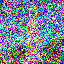
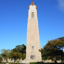
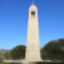

In [19]:
def iterative_denoise(im_noisy, i_start, prompt_embeds, timesteps, display=True):
  image = im_noisy

  with torch.no_grad():
    for i in range(i_start, len(timesteps) - 1):
      # Get timesteps
      t = timesteps[i]
      prev_t = timesteps[i+1]

      # get `alpha_cumprod` and `alpha_cumprod_prev` for timestep t from `alphas_cumprod`
      # compute `alpha`
      # compute `beta`
      # ===== your code here! =====
      alpha_cumprod = alphas_cumprod[t].item()
      alpha_cumprod_prev = alphas_cumprod[prev_t].item()
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha
      # ===== end of code =====

      # Get noise estimate
      model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est, predicted_variance = torch.split(model_output, image.shape[1], dim=1)

      # compute `pred_prev_image` (x_{t'}), the DDPM estimate for the image at the
      # next timestep, which is slightly less noisy.
      # ===== your code here! =====
      x0 = (image - (1 - alpha_cumprod) ** 0.5 * noise_est) / (alpha_cumprod ** 0.5)

      pred_prev_image = (
          (alpha_cumprod_prev ** 0.5) * beta / (1 - alpha_cumprod) * x0
          + (alpha ** 0.5) * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod) * image
      )

      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)


      # ===== end of code =====

      image = pred_prev_image

    clean = image.cpu().detach().numpy()

  return clean

# Please use this prompt embedding
prompt_embeds = prompt_embeds_dict["a high quality photo"]

# Add noise
i_start = 10
t = strided_timesteps[i_start]
im_noisy = forward(test_im, t).half().to(device)

# Denoise
clean = iterative_denoise(im_noisy,
                          i_start=i_start,
                          prompt_embeds=prompt_embeds,
                          timesteps=strided_timesteps)


# Compute the one step estimate of the clean image. Feel free to copy and paste
# code from part (a) above (one-step denoising). Store the image into `clean_one_step`
# ===== your code here! =====

with torch.no_grad():
  model_output = stage_1.unet(
      im_noisy,
      t,
      encoder_hidden_states=prompt_embeds,
      return_dict=False
  )[0]
  noise_est_os = model_output[:, :3]
  ac = alphas_cumprod[t].item()
  clean_one_step = (im_noisy - (1 - ac) ** 0.5 * noise_est_os) / (ac ** 0.5)
  clean_one_step = clean_one_step.float().cpu().detach().numpy()

# ===== end of code =====

media.show_images({
    'noisy (i_start=10)': im_noisy.float().cpu()[0].permute(1, 2, 0) / 2. + 0.5,
    'iterative': clean[0].transpose(1, 2, 0) / 2. + 0.5,
    'one-step': clean_one_step[0].transpose(1, 2, 0) / 2. + 0.5,
})


# 1.3 Sampling: With and Without Classifier-Free Guidance (CFG)

Another thing we can do with `iterative_denoise` is generate images completely from scratch. We can do this by setting $i\_start = 0$ and passing in random noise as `im_noisy`. This effectively denoises pure noise into a realistic-looking image, using the prompt embedding as the only signal.

You may notice that these plain samples are not very good. Classifier-Free Guidance ([CFG](https://arxiv.org/abs/2207.12598)) is a technique that greatly improves image quality (at the expense of image diversity) by extrapolating away from the unconditional noise estimate:
$$\epsilon_{cfg} = \epsilon_u + \gamma (\epsilon_c - \epsilon_u)$$
where $\epsilon_c$ and $\epsilon_u$ are the conditional and unconditional noise estimates, and $\gamma$ controls the strength of guidance ($\gamma = 1$ recovers standard conditional sampling).

Implement both plain sampling (reusing `iterative_denoise`) and CFG sampling (`iterative_denoise_cfg` below) so you can directly compare them.

### Deliverables
- 5 images of `"a high quality photo"`, sampled from scratch **without** CFG (using `iterative_denoise`)
- 5 images of the same prompt, sampled from scratch **with** CFG at $\gamma = 7$ (using `iterative_denoise_cfg`)
- A brief discussion of the visual difference between the two sets


no CFG,no CFG,no CFG,no CFG,no CFG

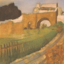
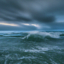
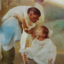
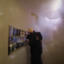
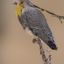

CFG = 7,CFG = 7,CFG = 7,CFG = 7,CFG = 7

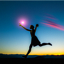
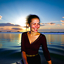
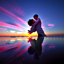
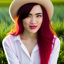
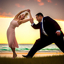

In [20]:
# The conditional prompt embedding
prompt_embeds = prompt_embeds_dict['a high quality photo']

# The unconditional prompt embedding
uncond_prompt_embeds = prompt_embeds_dict['']


def iterative_denoise_cfg(im_noisy, i_start, prompt_embeds, uncond_prompt_embeds, timesteps, scale=7, display=True):
  image = im_noisy

  with torch.no_grad():
    for i in range(i_start, len(timesteps) - 1):
      # Get timesteps
      t = timesteps[i]
      prev_t = timesteps[i+1]

      # Get `alpha_cumprod`, `alpha_cumprod_prev`, `alpha`, `beta`
      # ===== your code here! =====
      alpha_cumprod = alphas_cumprod[t].item()
      alpha_cumprod_prev = alphas_cumprod[prev_t].item()
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha

      # ===== end of code =====

      # Get cond noise estimate
      model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=prompt_embeds,
          return_dict=False
      )[0]

      # Get uncond noise estimate
      uncond_model_output = stage_1.unet(
          image,
          t,
          encoder_hidden_states=uncond_prompt_embeds,
          return_dict=False
      )[0]

      # Split estimate into noise and variance estimate
      noise_est, predicted_variance = torch.split(model_output, image.shape[1], dim=1)
      uncond_noise_est, _ = torch.split(uncond_model_output, image.shape[1], dim=1)

      # Compute the CFG noise estimate based on equation 4
      # ===== your code here! =====
      noise_est = uncond_noise_est + scale * (noise_est - uncond_noise_est)

      # ===== end of code =====


      # Get `pred_prev_image`, the next less noisy image.
      # ===== your code here! =====
      x0 = (image - (1 - alpha_cumprod) ** 0.5 * noise_est) / (alpha_cumprod ** 0.5)
      pred_prev_image = (
          (alpha_cumprod_prev ** 0.5) * beta / (1 - alpha_cumprod) * x0
          + (alpha ** 0.5) * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod) * image
      )
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)

      # ===== end of code =====

      image = pred_prev_image

    clean = image.cpu().detach().numpy()

  return clean

prompt_embeds = prompt_embeds_dict['a high quality photo']
uncond_prompt_embeds = prompt_embeds_dict['']

# Without CFG (reusing iterative_denoise from Task 1.2)
plain_samples = []
for _ in range(5):
    noise = torch.randn(1, 3, 64, 64).half().to(device)
    clean = iterative_denoise(noise, i_start=0,
                              prompt_embeds=prompt_embeds,
                              timesteps=strided_timesteps)
    plain_samples.append(clean[0].transpose(1, 2, 0) / 2. + 0.5)
media.show_images(plain_samples, titles=['no CFG'] * 5)

# With CFG at gamma = 7
cfg_samples = []
for _ in range(5):
    noise = torch.randn(1, 3, 64, 64).half().to(device)
    clean = iterative_denoise_cfg(noise, i_start=0,
                                  prompt_embeds=prompt_embeds,
                                  uncond_prompt_embeds=uncond_prompt_embeds,
                                  timesteps=strided_timesteps, scale=7)
    cfg_samples.append(clean[0].transpose(1, 2, 0) / 2. + 0.5)
media.show_images(cfg_samples, titles=['CFG = 7'] * 5)


# Part 2: Image Editing

## 2.1 Image-to-image Translation (SDEdit)

In Part 1.2, we implemented iterative denoising, which takes a real image, adds noise to it, and then denoises it back out. This effectively allows us to make edits to existing images: the more noise we add, the larger the edit will be. This works because in order to denoise an image, the diffusion model must to some extent "hallucinate" new things -- sometimes weird things, but often the same underlying idea as the original image, given a strong enough prior. This is the idea behind [SDEdit](https://sde-edit.github.io/).


In [21]:
# The conditional prompt embedding
prompt_embeds = prompt_embeds_dict['a high quality photo']

# The unconditional prompt embedding
uncond_prompt_embeds = prompt_embeds_dict['']


100%|██████████| 6/6 [00:25<00:00,  4.32s/it]


original,i_start=1,i_start=3,i_start=5,i_start=7,i_start=10,i_start=20

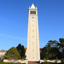
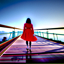
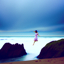
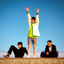
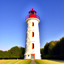
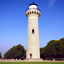
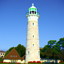

In [22]:
prompt_embeds = prompt_embeds_dict["a high quality photo"]
uncond_prompt_embeds = prompt_embeds_dict['']

imgs_dict = {'original': test_im[0].permute(1, 2, 0) / 2. + 0.5}
for i_start in tqdm([1, 3, 5, 7, 10, 20]):
    t = strided_timesteps[i_start]
    im_noisy = forward(test_im, t).half().to(device)
    clean = iterative_denoise_cfg(im_noisy,
                                  i_start=i_start,
                                  prompt_embeds=prompt_embeds,
                                  uncond_prompt_embeds=uncond_prompt_embeds,
                                  timesteps=strided_timesteps,
                                  display=False)
    imgs_dict[f'i_start={i_start}'] = clean[0].transpose(1, 2, 0) / 2. + 0.5
media.show_images(imgs_dict)


### 2.1.1 Editing Hand-Drawn and Web Images

This procedure works particularly well if we start with a nonrealistic image (e.g. painting, a sketch, some scribbles) and project it onto the natural image manifold.

**You only need to complete ONE of the two options below** (a web image or a hand-drawn image) for the required deliverable -- doing both is fine but not required for full credit.

### Deliverables
- Your starting image (whichever option you pick)
- Edits of the image at noise levels [1, 3, 5, 7, 10, 20]


In [23]:
# @title Function to Process Images

def process_pil_im(img):
  '''
  Transform a PIL image
  '''

  # Convert to RGB
  img = img.convert('RGB')

  # Define the transform to resize, convert to tensor, and normalize to [-1, 1]
  transform = transforms.Compose([
      transforms.Resize(64),               # Resize shortest side to 64
      transforms.CenterCrop(64),             # Center crop
      transforms.ToTensor(),               # Convert image to PyTorch tensor with range [0, 1]
      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to range [-1, 1]
  ])

  # Apply the transformations and add batch dim
  img = transform(img)[None]

  # Show image
  print("Processed image")
  media.show_image(img[0].permute(1,2,0) / 2 + 0.5)

  return img

Processed image


""

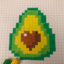

In [24]:
# @title Download Images from Web

################
## CHANGE URL ##
################
url = "https://i.pinimg.com/originals/76/e5/d5/76e5d55d0c8c6ec65135b42a2c5cbd98.jpg"
################
################

# Download image from URL and process
response = requests.get(url)
web_im = Image.open(BytesIO(response.content))
web_im = process_pil_im(web_im)

100%|██████████| 6/6 [00:26<00:00,  4.39s/it]


1,3,5,7,10,20

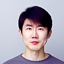
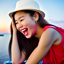
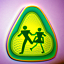
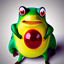
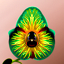
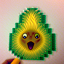

In [25]:
prompt_embeds = prompt_embeds_dict["a high quality photo"]
uncond_prompt_embeds = prompt_embeds_dict['']

imgs_dict = {}
for i_start in tqdm([1, 3, 5, 7, 10, 20]):
  # Add noise
  t = strided_timesteps[i_start]
  im_noisy = forward(web_im, t).half().to(device)

  # Denoise
  clean = iterative_denoise_cfg(im_noisy,
                                i_start=i_start,
                                prompt_embeds=prompt_embeds,
                                uncond_prompt_embeds=uncond_prompt_embeds,
                                timesteps=strided_timesteps,
                                display=False)

  # Add to dict to display later
  imgs_dict[i_start] = clean[0].transpose(1,2,0) / 2. + 0.5

media.show_images(imgs_dict)

Processed image


""

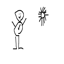

In [26]:
# @title Hand Drawn Images

############
### N.B. ###
############

# This code is from: https://gist.github.com/karim23657/5ad5e067c1684dbc76c93bd88bf6fa53
# The board is hardcoded to be size 300 x 600, but we're using square images
# so please just draw in the center of the board
# In addition, this gist may be taken down or change location,
# which will break things in the future

############
############

from base64 import b64decode
from IPython.display import HTML
from google.colab.output import eval_js
import urllib.request
board_html = urllib.request.urlopen('https://gist.githubusercontent.com/karim23657/5ad5e067c1684dbc76c93bd88bf6fa53/raw/2ef57f881bc700c2c346bd6c7a7f2d5364b21048/drawing%2520board.html').read().decode('utf-8')

def draw(filename='drawing.png'):
  display(HTML(board_html))
  data = eval_js('triggerImageToServer')
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return Image.open(filename).convert('RGB')

drawn_im = draw('myImage.png').resize((64,64))
drawn_im = process_pil_im(drawn_im)


100%|██████████| 6/6 [00:25<00:00,  4.33s/it]


1,3,5,7,10,20

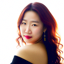
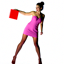
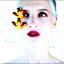
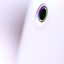
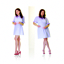
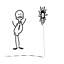

In [27]:
prompt_embeds = prompt_embeds_dict["a high quality photo"]
uncond_prompt_embeds = prompt_embeds_dict['']

imgs_dict = {}
for i_start in tqdm([1, 3, 5, 7, 10, 20]):
  # Add noise
  t = strided_timesteps[i_start]
  im_noisy = forward(drawn_im, t).half().to(device)

  # Denoise
  clean = iterative_denoise_cfg(im_noisy,
                                i_start=i_start,
                                prompt_embeds=prompt_embeds,
                                uncond_prompt_embeds=uncond_prompt_embeds,
                                timesteps=strided_timesteps,
                                display=False)

  # Add to dict to display later
  imgs_dict[i_start] = clean[0].transpose(1,2,0) / 2. + 0.5

media.show_images(imgs_dict)

## 2.2 Inpainting

We can use the same procedure to implement inpainting (following the [RePaint](https://arxiv.org/abs/2201.09865) paper). That is, given an image $x_{orig}$, and a binary mask $\bf m$, we can create a new image that has the same content where $\bf m$ is 0, but new content wherever $\bf m$ is 1. We can do this by using the diffusion model to generate new content inside the mask, while resetting everything outside the mask back to the original image (properly noised for the current timestep) at every step of the loop.

### Deliverables
- Inpainted image of the provided test image (using the provided mask)
- Inpainted image of **one image of your own choosing**, with your own mask


Image,Mask,To Replace

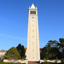
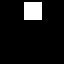
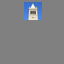

In [28]:
# EDIT ME!
# Make mask
mask = torch.zeros_like(test_im)
mask[:, :, 2:20, 24:42] = 1.0
mask = mask.to(device)

# Visualize mask
media.show_images({
    'Image': test_im[0].permute(1,2,0) / 2. + 0.5,
    'Mask': mask.cpu()[0].permute(1,2,0),
    'To Replace': (test_im * mask.cpu())[0].permute(1,2,0) / 2. + 0.5,
})

original,mask,inpainted

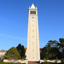
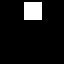
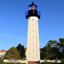

In [29]:
def inpaint(original_image, mask, prompt_embeds, uncond_prompt_embeds, timesteps, scale=7, display=True):
  """
  Args:
    original_image : torch tensor of size (1, 3, 64, 64), the image to inpaint
    mask : torch tensor of size (1, 3, 64, 64), 1 where the model may generate
           new content, 0 where the original image should be preserved
    prompt_embeds, uncond_prompt_embeds, timesteps, scale : same as iterative_denoise_cfg

  Returns:
    clean : numpy array of size (1, 3, 64, 64), the inpainted image
  """
  original_image = original_image.to(device).half()
  mask = mask.to(device).half()

  image = torch.randn_like(original_image).to(device).half()

  # This will look a lot like iterative_denoise_cfg, with one key addition:
  # at every step, force everything OUTSIDE the mask back to the original
  # image (re-noised to match the current timestep), so only the masked
  # region is free to change.
  # ===== your code here! =====

  with torch.no_grad():
    for i in range(len(timesteps) - 1):
      t = timesteps[i]
      prev_t = timesteps[i+1]

      alpha_cumprod = alphas_cumprod[t].item()
      alpha_cumprod_prev = alphas_cumprod[prev_t].item()
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha


      model_output = stage_1.unet(
          image, t, encoder_hidden_states=prompt_embeds, return_dict=False)[0]
      uncond_model_output = stage_1.unet(
          image, t, encoder_hidden_states=uncond_prompt_embeds, return_dict=False)[0]
      noise_est, predicted_variance = torch.split(model_output, image.shape[1], dim=1)
      uncond_noise_est, _ = torch.split(uncond_model_output, image.shape[1], dim=1)
      noise_est = uncond_noise_est + scale * (noise_est - uncond_noise_est)


      x0 = (image - (1 - alpha_cumprod) ** 0.5 * noise_est) / (alpha_cumprod ** 0.5)
      pred_prev_image = (
          (alpha_cumprod_prev ** 0.5) * beta / (1 - alpha_cumprod) * x0
          + (alpha ** 0.5) * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod) * image
      )
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)
      image = pred_prev_image


      noised_original = (alpha_cumprod_prev ** 0.5) * original_image \
          + (1 - alpha_cumprod_prev) ** 0.5 * torch.randn_like(original_image)
      image = mask * image + (1 - mask) * noised_original

    clean = image.float().cpu().detach().numpy()

  return clean

  # ===== end of code =====
prompt_embeds = prompt_embeds_dict['a high quality photo']
uncond_prompt_embeds = prompt_embeds_dict['']

inpainted = inpaint(test_im, mask, prompt_embeds, uncond_prompt_embeds, strided_timesteps)
media.show_images({
    'original': test_im[0].permute(1, 2, 0) / 2. + 0.5,
    'mask': mask.cpu()[0].permute(1, 2, 0),
    'inpainted': inpainted[0].transpose(1, 2, 0) / 2. + 0.5,
})


original,mask,inpainted

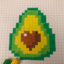
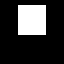
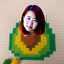

In [30]:
my_im = web_im

my_mask = torch.zeros_like(my_im)
my_mask[:, :, 5:35, 18:46] = 1.0
my_mask = my_mask.to(device)

prompt_embeds = prompt_embeds_dict['a high quality photo']
uncond_prompt_embeds = prompt_embeds_dict['']

my_inpainted = inpaint(my_im, my_mask, prompt_embeds, uncond_prompt_embeds, strided_timesteps)
media.show_images({
    'original': my_im[0].permute(1, 2, 0) / 2. + 0.5,
    'mask': my_mask.cpu()[0].permute(1, 2, 0),
    'inpainted': my_inpainted[0].transpose(1, 2, 0) / 2. + 0.5,
})


## 2.3 Text-Conditioned Image-to-image Translation

Now, we will do the same thing as in 2.1, but guide the projection with a text prompt instead of the default `"a high quality photo"`. This is no longer pure "projection onto the natural image manifold" -- it also steers the projection using language. This is simply a matter of changing the prompt passed into `iterative_denoise_cfg`.

### Deliverables
- Edits of the provided test image at noise levels [1, 3, 5, 7, 10, 20], using a text prompt of your choice (not `"a high quality photo"`)
- State which prompt you used


100%|██████████| 6/6 [00:25<00:00,  4.26s/it]

Prompt used: a rocket ship


i_start=1,i_start=3,i_start=5,i_start=7,i_start=10,i_start=20

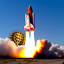
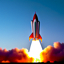
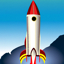
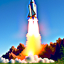
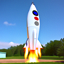
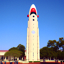

In [31]:
uncond_prompt_embeds = prompt_embeds_dict['']

# ===== your code here! =====

chosen_prompt = "a rocket ship"
prompt_embeds = prompt_embeds_dict[chosen_prompt]

imgs_dict = {}
for i_start in tqdm([1, 3, 5, 7, 10, 20]):
    t = strided_timesteps[i_start]
    im_noisy = forward(test_im, t).half().to(device)
    clean = iterative_denoise_cfg(im_noisy,
                                  i_start=i_start,
                                  prompt_embeds=prompt_embeds,
                                  uncond_prompt_embeds=uncond_prompt_embeds,
                                  timesteps=strided_timesteps,
                                  display=False)
    imgs_dict[f'i_start={i_start}'] = clean[0].transpose(1, 2, 0) / 2. + 0.5

print(f"Prompt used: {chosen_prompt}")
media.show_images(imgs_dict)

# ===== end of code =====

# Part 3: Diffusion Illusions

## 3.1 Visual Anagrams

In this part, we are finally ready to implement [Visual Anagrams](https://dangeng.github.io/visual_anagrams/) and create optical illusions with diffusion models. We will create an image that looks like one thing right-side up, but a different thing when flipped upside down.

We do this by estimating the noise for the image with one prompt, and estimating the noise for the *flipped* image with a different prompt, flipping that second estimate back, and averaging the two:
$$\epsilon_1 = \text{UNet}(x_t, t, p_1)$$
$$\epsilon_2 = \text{flip}(\text{UNet}(\text{flip}(x_t), t, p_2))$$
$$\epsilon = \frac{\epsilon_1 + \epsilon_2}{2}$$

### Deliverables
- Your visual anagram (both orientations), along with the two prompts you used


upright: an old man,flipped: people around a campfire

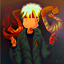
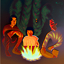

In [32]:
def make_flip_illusion(image, i_start, prompt_embeds, uncond_prompt_embeds, timesteps, scale=7, display=True):
  """
  Args:
    image : torch tensor of size (1, 3, 64, 64), starting noise (or partially noised image)
    prompt_embeds : tuple of two prompt embeddings (p1, p2) -- p1 conditions the
                    upright orientation, p2 conditions the flipped orientation
    uncond_prompt_embeds, i_start, timesteps, scale : same as iterative_denoise_cfg

  Returns:
    clean : numpy array of size (1, 3, 64, 64), the anagram image (upright orientation)
  """
  # At each step: estimate the CFG noise for the image normally with p1, estimate
  # the CFG noise for the *flipped* image with p2 and flip that estimate back,
  # then average the two before taking the reverse step. See Task 3.1 in the
  # assignment PDF for the exact formula.
  # ===== your code here! =====

  p1, p2 = prompt_embeds

  def cfg_noise(img, p):
    out = stage_1.unet(img, t, encoder_hidden_states=p, return_dict=False)[0]
    unc = stage_1.unet(img, t, encoder_hidden_states=uncond_prompt_embeds, return_dict=False)[0]
    n, pv = torch.split(out, img.shape[1], dim=1)
    un, _ = torch.split(unc, img.shape[1], dim=1)
    return un + scale * (n - un), pv

  with torch.no_grad():
    for i in range(i_start, len(timesteps) - 1):
      t = timesteps[i]
      prev_t = timesteps[i+1]

      alpha_cumprod = alphas_cumprod[t].item()
      alpha_cumprod_prev = alphas_cumprod[prev_t].item()
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha

      # eps_1 = UNet(x_t, t, p1) ; use its variance for the reverse step
      eps1, predicted_variance = cfg_noise(image, p1)

      # eps_2 = flip(UNet(flip(x_t), t, p2)) -- flip along the height axis (dim 2)
      flipped = torch.flip(image, dims=[2])
      eps2, _ = cfg_noise(flipped, p2)
      eps2 = torch.flip(eps2, dims=[2])

      # average the two noise estimates
      noise_est = (eps1 + eps2) / 2

      x0 = (image - (1 - alpha_cumprod) ** 0.5 * noise_est) / (alpha_cumprod ** 0.5)
      pred_prev_image = (
          (alpha_cumprod_prev ** 0.5) * beta / (1 - alpha_cumprod) * x0
          + (alpha ** 0.5) * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod) * image
      )
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)
      image = pred_prev_image

    clean = image.float().cpu().detach().numpy()

  return clean
  # ===== end of code =====
p1 = prompt_embeds_dict["an oil painting of an old man"]
p2 = prompt_embeds_dict["an oil painting of people around a campfire"]
uncond_prompt_embeds = prompt_embeds_dict['']

noise = torch.randn(1, 3, 64, 64).half().to(device)
clean = make_flip_illusion(noise, i_start=0,
                           prompt_embeds=(p1, p2),
                           uncond_prompt_embeds=uncond_prompt_embeds,
                           timesteps=strided_timesteps, scale=7)

upright = clean[0].transpose(1, 2, 0) / 2. + 0.5
media.show_images({
    'upright: an old man': upright,
    'flipped: people around a campfire': upright[::-1],
})



## 3.2 Hybrid Images (Bonus)

This subsection is optional and worth bonus credit -- there is no penalty for skipping it.

A **hybrid image** is a classic image-compositing trick: take the low spatial frequencies of one image and the high spatial frequencies of another, add them together, and the result reads as one thing from a distance (or with blurred vision) and a different thing up close -- because human perception weights low frequencies more at a distance and high frequencies more up close.

We can create a diffusion-model version of this ([Factorized Diffusion](https://dangeng.github.io/factorized_diffusion/)) by applying the same low-pass/high-pass trick to the model's *noise estimates* rather than to pixels directly: taking the low frequencies of one prompt's noise estimate and the high frequencies of a different prompt's noise estimate, and adding them together:
$$\epsilon = f_{low}(\text{UNet}(x_t, t, p_1)) + f_{high}(\text{UNet}(x_t, t, p_2))$$

### Bonus Deliverables (optional)
- Your hybrid image, along with the two prompts you used
- A brief note on which prompt dominates up close vs. from a distance

### Hint
Hybrid images work best when the two prompts describe subjects with a similar coarse silhouette (e.g. a skull and a waterfall, both roughly rounded/vertical), since the low-frequency prompt defines the overall shape and the high-frequency prompt only needs to fill in texture on top of it.


hybrid (far: waterfalls / near: skull)

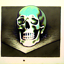

In [33]:
def make_hybrids(image, i_start, prompt_embeds, uncond_prompt_embeds, timesteps, scale=7, display=True):
  """
  Args:
    image : torch tensor of size (1, 3, 64, 64), starting noise (or partially noised image)
    prompt_embeds : tuple of two prompt embeddings (p_low, p_high) -- p_low
                    contributes low frequencies, p_high contributes high frequencies
    uncond_prompt_embeds, i_start, timesteps, scale : same as iterative_denoise_cfg

  Returns:
    clean : numpy array of size (1, 3, 64, 64), the hybrid image
  """
  # At each step: estimate the CFG noise for p_low and p_high separately, low-pass
  # the first (e.g. with a Gaussian blur), high-pass the second (the estimate minus
  # its own low-pass version), and add the two together before taking the reverse
  # step. See Task 3.2 in the assignment PDF for the exact formula.
  # ===== your code here! =====

  p_low, p_high = prompt_embeds

  def cfg_noise(img, p):
    out = stage_1.unet(img, t, encoder_hidden_states=p, return_dict=False)[0]
    unc = stage_1.unet(img, t, encoder_hidden_states=uncond_prompt_embeds, return_dict=False)[0]
    n, pv = torch.split(out, img.shape[1], dim=1)
    un, _ = torch.split(unc, img.shape[1], dim=1)
    return un + scale * (n - un), pv

  def lowpass(x):
    # Gaussian blur keeps only low spatial frequencies
    return TF.gaussian_blur(x, kernel_size=9, sigma=2.0)

  with torch.no_grad():
    for i in range(i_start, len(timesteps) - 1):
      t = timesteps[i]
      prev_t = timesteps[i+1]

      alpha_cumprod = alphas_cumprod[t].item()
      alpha_cumprod_prev = alphas_cumprod[prev_t].item()
      alpha = alpha_cumprod / alpha_cumprod_prev
      beta = 1 - alpha

      eps_low, predicted_variance = cfg_noise(image, p_low)
      eps_high, _ = cfg_noise(image, p_high)

      # eps = f_low(eps_low) + f_high(eps_high), where f_high(x) = x - lowpass(x)
      noise_est = lowpass(eps_low) + (eps_high - lowpass(eps_high))

      x0 = (image - (1 - alpha_cumprod) ** 0.5 * noise_est) / (alpha_cumprod ** 0.5)
      pred_prev_image = (
          (alpha_cumprod_prev ** 0.5) * beta / (1 - alpha_cumprod) * x0
          + (alpha ** 0.5) * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod) * image
      )
      pred_prev_image = add_variance(predicted_variance, t, pred_prev_image)
      image = pred_prev_image

    clean = image.float().cpu().detach().numpy()

  return clean
  # ===== end of code =====
p_low = prompt_embeds_dict["a lithograph of waterfalls"]
p_high = prompt_embeds_dict["a lithograph of a skull"]
uncond_prompt_embeds = prompt_embeds_dict['']

noise = torch.randn(1, 3, 64, 64).half().to(device)
clean = make_hybrids(noise, i_start=0,
                     prompt_embeds=(p_low, p_high),
                     uncond_prompt_embeds=uncond_prompt_embeds,
                     timesteps=strided_timesteps, scale=7)
media.show_images({
    'hybrid (far: waterfalls / near: skull)': clean[0].transpose(1, 2, 0) / 2. + 0.5,
})


# [Optional] Upsampling Images

If you want to upsample your $64\times 64$ images to $256 \times 256$, you can use the following code: